## Validation Approach 1: Out-of-frame data as neutral baseline

Validate DASM entrenchment predictions by independently estimating selection from mutation counts, comparing productive (selected) vs out-of-frame/non-productive (neutral) sequences.

**Method**: For each V family, site, and amino acid substitution, we calculate the ratio of observed mutation rates (from productive sequences) to expected mutation rates (from out-of-frame sequences). Under the DASM framework, this ratio approximates the selection factor.

Rates are calculated only at V-gene-encoded sites, for mutations away from the germline amino acid. Out-of-frame sequences are in-frame within the V gene region, so sites can be annotated using the germline V gene alignment, enabling consistent comparison across datasets. The rate for each substitution is:

    rate = (mutation count + pseudocount) / branch length

where branch length is calculated per PCP as the synonymous nucleotide mutation frequency. We use synonymous mutation-based branch lengths because synonymous mutations experience comparable selective pressure in both productive and out-of-frame data (unlike nonsynonymous mutations, which are differentially selected). Although synonymous mutations are not perfectly neutral, any resulting bias in branch lengths cancels in the rate ratio because the same calculation is applied to both datasets.

For productive sequences, leaf nodes are excluded to focus on mutations that have undergone subsequent rounds of selection. For out-of-frame sequences, all PCPs are included to maximize data and since selection is not relevant here.

**Datasets**: Rodriguez (productive, held-out test set) and Tang-SHM (out-of-frame, neutral baseline). These come from different individuals. See paper Methods and Table 1 for details.

**Analysis levels**:
1. Per site (any mutation away from germline) — compared to DNSM selection factors
2. Per site + parent codon + child codon — validates that synonymous mutations cluster near neutral while nonsynonymous mutations skew toward purifying selection
3. Per site + parent AA + child AA — compared to DASM selection factors

**Key results**:
- DNSM and DASM selection factors correlate well with independently estimated rate ratios.
- Synonymous codon mutations cluster around neutral (log ratio ≈ 0), as expected.
- Many substitutions lack sufficient out-of-frame counts (≥5 required), retaining ~1,200 of ~3,200 substitutions. This motivates the complementary Thrifty-based validation (Approach 2).
- Entrenched sites that pass filtering consistently show purifying selection.

**Saved figures**: `rodriguez_rates_w_oof*` (DASM vs rate ratio scatter and pairwise entrenchment validation).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from netam.sequences import nt_mask_tensor_of, AA_STR_SORTED, CODONS, translate_codon
from netam.framework import encode_mut_pos_and_base

from shmex.shm_data import pcp_df_of_non_shmoof_nickname

from utils import (
    add_column_aa_one_mutation_away_from_aa,
    sort_antibody_sites,
    add_cdr_shading,
    add_germline_information,
    load_and_process_dnsm_data,
    load_and_process_dasm_data,
    load_entrenched_sites,
    GERMLINE_PATH_DICTIONARY,
)

from rates_analysis_util import (
    compare_mutation_rates_on_different_backgrounds_for_all_sites,
    add_mutation_counts_per_branch_for_branch_length,
    plot_dasm_vs_rates_comparison,
    plot_rates_pairwise_analysis,
    orthogonal_regression,
)



In [2]:
DATASET_SHM = "tangshm"

DATASET_PRODUCTIVE = 'v1rodriguez'

numbering_scheme = 'chothia'

branch_length_method = 'synonymous_mutation_freq_branch'

# entrenchment analysis comparison parameters
dasm_compare_dataset_name = "v1rodriguez"
dasm_compare_model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"

In [3]:
### prepare shm out of frame data
### adapted from thrifty-experiments-1


def ragged_np_pcp_encoding(parents, children, site_count=None):
    """
    Encode the mutation indicators, base indices, and masks of a list of
    parent-child pairs.
    """
    mutation_indicator_list = []
    mask_list = []
    for parent, child in zip(parents, children):
        mutation_indicators, _ = encode_mut_pos_and_base(parent, child)
        mutation_indicator_list.append(mutation_indicators.numpy()[:site_count])
        mask_list.append(nt_mask_tensor_of(child).numpy()[:site_count])
    return mutation_indicator_list, mask_list


def detailed_site_df_for(pcp_df):
    """Create a DataFrame with every site, mutation status, branch length, v_gene, and sequence details"""
    mut_indicators, masks = ragged_np_pcp_encoding(
        pcp_df["parent"], pcp_df["child"]
    )
    val_bls = pcp_df["branch_length"].values
    
    detailed_rows = []
    
    for seq_idx, (mask, branch_length, mut_indicator, v_gene, parent_seq, child_seq) in enumerate(
        zip(masks, val_bls, mut_indicators, pcp_df["v_gene"], pcp_df["parent"], pcp_df["child"])
    ):
        
        # For each site in this sequence
        for site_idx in range(len(parent_seq)):
            if mask[site_idx]:  # Only include valid sites
                # Get nucleotides
                parent_nt = parent_seq[site_idx] if site_idx < len(parent_seq) else 'N'
                child_nt = child_seq[site_idx] if site_idx < len(child_seq) else 'N'
                
                # Get codon information (which codon this site belongs to)
                codon_idx = (site_idx // 3)
                codon_position = site_idx % 3  # Position within codon (0, 1, or 2)
                
                # Extract parent and child codons
                codon_start = codon_idx * 3
                codon_end = codon_start + 3
                
                parent_codon = parent_seq[codon_start:codon_end] if codon_end <= len(parent_seq) else 'NNN'
                child_codon = child_seq[codon_start:codon_end] if codon_end <= len(child_seq) else 'NNN'
                
                # Translate codons to amino acids
                try:
                    from Bio.Seq import Seq
                    parent_aa = str(Seq(parent_codon).translate()) if len(parent_codon) == 3 else 'X'
                    child_aa = str(Seq(child_codon).translate()) if len(child_codon) == 3 else 'X'
                except:
                    parent_aa = 'X'
                    child_aa = 'X'
                
                detailed_rows.append({
                    'pcp_index': seq_idx,
                    'nt_site': site_idx,
                    'site': codon_idx + 1,
                    'codon_position': codon_position,
                    'mutation': bool(mut_indicator[site_idx]),
                    'branch_length': branch_length,
                    'v_gene': v_gene,
                    'v_family': v_gene.split('-')[0] if '-' in str(v_gene) else v_gene,
                    'parent_nt': parent_nt,
                    'child_nt': child_nt,
                    'parent_codon': parent_codon,
                    'child_codon': child_codon,
                    'parent_aa': parent_aa,
                    'child_aa': child_aa,
                })
    
    return pd.DataFrame(detailed_rows)


def create_detailed_site_data(
    dataset_names,  # Changed: now accepts str or list
    numbering_scheme='imgt',
):
    """
    Create detailed site-level data for single or multiple datasets.

    Parameters:
    -----------
    dataset_names : str or list of str
        Single dataset name or list of dataset names to combine
    numbering_scheme : str
        'imgt' or 'chothia'

    Returns:
    --------
    tuple : (pcp_df, detailed_nuc_site_df, detailed_site_df)
    """
    # Handle both single string and list
    if isinstance(dataset_names, str):
        dataset_names = [dataset_names]

    # Load all datasets
    pcp_dfs = []
    for dataset_name in dataset_names:
        pcp_df = pcp_df_of_non_shmoof_nickname(dataset_name)
        pcp_dfs.append(pcp_df)

    # CRITICAL: Combine with proper index reset
    pcp_df = pd.concat(pcp_dfs).reset_index(drop=True)

    # Optional: Track source dataset
    if len(dataset_names) > 1:
        cumulative_lens = [0] + list(pd.Series([len(df) for df in pcp_dfs]).cumsum())
        pcp_df['source_dataset'] = ''
        for i, dataset_name in enumerate(dataset_names):
            start_idx = cumulative_lens[i]
            end_idx = cumulative_lens[i + 1]
            pcp_df.loc[start_idx:end_idx-1, 'source_dataset'] = dataset_name

    # Create detailed site data for all sequences
    # This now uses the combined pcp_df
    detailed_site_list = []
    detailed_all = detailed_site_df_for(pcp_df)
    detailed_site_list.append(detailed_all)
    
    # Combine all detailed data
    detailed_site_df = pd.concat(detailed_site_list, ignore_index=True)
    
    # add germline information
    ## Non producive pcps are only out of frame in the VDJ junction, as sequences with indels acquired during affinity maturation are filtered out.
    ## Consequently, the V gene part of the sequence is always in frame and can be compared to the germline V gene sequence.
    ## germline_codons_df is IMGT/chothia aligned so we use that to get alignemnt for the non prouctive sequences.
    germline_codons_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})
    germline_codons_df['rank'] = germline_codons_df.groupby('v_gene', sort=False).cumcount() + 1
    detailed_site_df_germline = pd.merge(detailed_site_df.rename(columns={'site':'rank'}), germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}), on=['v_family', 'v_gene', 'rank'], how='left')
    detailed_site_df_germline['is_germline_codon'] = detailed_site_df_germline['parent_codon'] == detailed_site_df_germline['germline_codon']
    detailed_site_df_germline['is_germline_aa'] = detailed_site_df_germline['parent_aa'] == detailed_site_df_germline['germline_amino_acid']

    # remove rows with N in parent or child codon
    detailed_site_df_germline = detailed_site_df_germline[(~detailed_site_df_germline.parent_codon.str.contains('N')) & (~detailed_site_df_germline.child_codon.str.contains('N'))]

    # remove rows with Na in site (not in v gene region)
    detailed_site_df_germline = detailed_site_df_germline[~detailed_site_df_germline.site.isna()]

    # collapse nucleotide to site level analysis
    detailed_site_df_germline_per_site = detailed_site_df_germline[['pcp_index',
    'branch_length', 'v_gene', 'v_family',
    'parent_codon', 'child_codon', 'parent_aa', 'child_aa', 'site',
    'germline_codon', 'germline_amino_acid', 'is_germline_codon',
    'is_germline_aa', 'rank']].drop_duplicates().drop(columns='rank')

    # Convert site to categorical with proper antibody numbering order
    detailed_site_df_germline_per_site['site'] = pd.Categorical(
        detailed_site_df_germline_per_site['site'], 
        categories=sort_antibody_sites(detailed_site_df_germline_per_site['site'].unique()), 
        ordered=True
    )

    # Now sort by pcp_index and site (with proper antibody ordering)
    detailed_site_df_germline_per_site = detailed_site_df_germline_per_site.sort_values(by=['pcp_index', 'site'])

    # Add nucleotide mutations frequency per branch as an alternative to branch length
    # Uses shared function from rates_analysis_util
    detailed_site_df_germline_per_site = add_mutation_counts_per_branch_for_branch_length(detailed_site_df_germline_per_site)
    
    return pcp_df, detailed_site_df_germline, detailed_site_df_germline_per_site


# Create the detailed site data
pcp_df_neutral, detailed_nuc_site_df_neutral, detailed_site_df_neutral = create_detailed_site_data(
    dataset_names=DATASET_SHM, numbering_scheme=numbering_scheme
)

Loading /home/nharel/data/v1/tang-deepshm-oof_pcp_2024-04-09_MASKED_NI.csv.gz


Loaded 7000 PCPs from tangshm


In [4]:
## load and prepare data for **observed** mutation rates using counts
## Note: add_mutation_counts_per_branch_for_branch_length is now imported from rates_analysis_util

In [5]:
## calculate observed and expected mutation rates
## 
## LEAF FILTERING DISABLED: Including leaves to answer KS question

output_dirs = '_ignore/observed_counts_from_productive', '_ignore/expected_counts_from_non_productive'

for dir in output_dirs:
    if not os.path.exists(dir):
        os.mkdir(dir)


observed_output_base_path = f'_ignore/observed_counts_from_productive/observed_mutation_rates_{DATASET_PRODUCTIVE}_bl_{branch_length_method}_{numbering_scheme}_with_leaves'
# calcualte observed mutation rates from productive data (DNSM outputs aren't used here)
site_sub_probs_df_germline_total, total_pcp_df = load_and_process_dnsm_data(model_name = "dnsm_1m-v1jaffe+v1tang-joint", dataset_name=DATASET_PRODUCTIVE, numbering_scheme=numbering_scheme)
site_sub_probs_df_germline_total = add_mutation_counts_per_branch_for_branch_length(site_sub_probs_df_germline_total)
compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline_total,  observed_output_base_path, branch_length_method=branch_length_method, remove_leaves=False, pcp_df=total_pcp_df)

# Generate dataset label for cache files
if isinstance(DATASET_SHM, list):
    dataset_label_shm = '+'.join(DATASET_SHM)
else:
    dataset_label_shm = DATASET_SHM

# calculate expected mutation rates from non productive data
expected_output_base_path = f'_ignore/expected_counts_from_non_productive/expected_mutation_rates_{dataset_label_shm}_bl_{branch_length_method}_{numbering_scheme}'
compare_mutation_rates_on_different_backgrounds_for_all_sites(detailed_site_df_neutral, expected_output_base_path, branch_length_method=branch_length_method, remove_leaves=False, pcp_df=pcp_df_neutral)

Processing 148 sites...
Processing site 1/148: site 1


Processing site 11/148: site 11


Processing site 21/148: site 21


Processing site 31/148: site 31


No data for V family IGHV1 at site 31A
No data for V family IGHV3 at site 31A


...

Processing site 81/102: site 80


Processing site 91/102: site 87


No data for V family IGHV1 at site 52B
No data for V family IGHV4 at site 52B
No data for V family IGHV1 at site 52C
No data for V family IGHV4 at site 52C
Processing site 101/102: site 31A
No data for V family IGHV1 at site 31A
No data for V family IGHV3 at site 31A


No data for V family IGHV1 at site 31B
No data for V family IGHV3 at site 31B
Converting results to DataFrames...
Saving overall results to _ignore/expected_counts_from_non_productive/expected_mutation_rates_tangshm_bl_synonymous_mutation_freq_branch_chothia_overall_mutation_rates.csv
Overall results: 297 rows saved
Saving per-amino acid results to _ignore/expected_counts_from_non_productive/expected_mutation_rates_tangshm_bl_synonymous_mutation_freq_branch_chothia_per_aa_mutation_rates.csv
Per-AA results: 10241 rows saved
Saving per-codon results to _ignore/expected_counts_from_non_productive/expected_mutation_rates_tangshm_bl_synonymous_mutation_freq_branch_chothia_per_codon_mutation_rates.csv
Per-codon results: 6255 rows saved


(    v_family site  mutcount_length  mutation_acquired  \
 0      IGHV1    1         5.003070                 11   
 1      IGHV3    1        11.332280                106   
 2      IGHV4    1         5.340343                 13   
 3      IGHV1    2         4.407512                 19   
 4      IGHV3    2        11.307614                 48   
 ..       ...  ...              ...                ...   
 292    IGHV4   94         3.623240                 32   
 293    IGHV3  52B         1.273509                 16   
 294    IGHV3  52C         1.037718                 27   
 295    IGHV4  31A         2.196983                 46   
 296    IGHV4  31B         1.348659                 64   
 
      mutation_acquired_adjusted  rate_mutcount  rate_mutcount_adjusted  
 0                          11.5       2.198650                2.298589  
 1                         106.5       9.353811                9.397933  
 2                          13.5       2.434301                2.527927  
 3    

## load entrenches sites identified by DASM analysis

We separate sites into two types of evolutionarily constrained sites:
- Within v family entrenched sites
- Between v-family entrenched sites

Below, when we higlight entrenched sites in the scatter plots, we have one version for all sites and then one version for the within v family entrenched sites, as those are the more surprising ones that we wanted to focus on in validation.


In [6]:
# Load entrenched sites using consolidated function from utils
entrenched_sites, entrenched_sites_aas, pairwise_df_dict, SITE_COLOR_MAP, within_dfs, vs_dfs = load_entrenched_sites(numbering_scheme)

print(f"Loaded {len(entrenched_sites)} entrenched site/v_family pairs")
print(f"Loaded {len(entrenched_sites_aas)} entrenched site/v_family/aa pairs")
print(f"Created color mapping for {len(SITE_COLOR_MAP)} sites")

Loaded 37 entrenched site/v_family pairs
Loaded 83 entrenched site/v_family/aa pairs
Created color mapping for 15 sites


## Rates per site (any germline aa to any aa)
- First let's compare do DNSM to see that this makes sense.
- Second - look at entrenched sites. They seem to have a very high expected rate, together with a pretty low observed mutation rate.


In [7]:

observed_df = pd.read_csv(f'{observed_output_base_path}_overall_mutation_rates.csv', dtype={'site':str})
expected_df = pd.read_csv(f'{expected_output_base_path}_overall_mutation_rates.csv', dtype={'site':str})

In [8]:
# compare dnsm log selection factors and log rate ratio of counts (observed / expected)
# aggregate by v_family and site

# site_sub_probs_df_germline_total already loaded in cell above

dnsm_summarized = site_sub_probs_df_germline_total[site_sub_probs_df_germline_total.is_germline_aa == True].groupby(['v_family', 'site']).selection_factor.median().reset_index()
dnsm_summarized['log_selection_factor'] = np.log(dnsm_summarized['selection_factor'])
dnsm_summarized['log_selection_factor'] = dnsm_summarized['log_selection_factor'].clip(lower=-4, upper=4)

rates_summarized = pd.merge(
    observed_df[['v_family', 'site', 'mutcount_length', 'mutation_acquired', 'mutation_acquired_adjusted', 'rate_mutcount', 'rate_mutcount_adjusted']],
    expected_df[['v_family', 'site', 'mutcount_length', 'mutation_acquired', 'mutation_acquired_adjusted', 'rate_mutcount', 'rate_mutcount_adjusted']],
    on=['site', 'v_family'],
    suffixes=('_observed', '_expected')
)

# Use adjusted rates (with pseudocount already applied at count level)
rates_summarized['ratio'] = rates_summarized['rate_mutcount_adjusted_observed'] / rates_summarized['rate_mutcount_adjusted_expected']
rates_summarized['log_ratio'] = np.log(rates_summarized['ratio'])
rates_summarized['log_ratio'] = rates_summarized['log_ratio'].clip(lower=-4, upper=4)

compare_rates_dnsm = pd.merge(rates_summarized, dnsm_summarized, on=['v_family', 'site'])

Text(0.5, 1.0, 'Log Rate Ratio Distribution (germline amino acid to any other amino acid)')

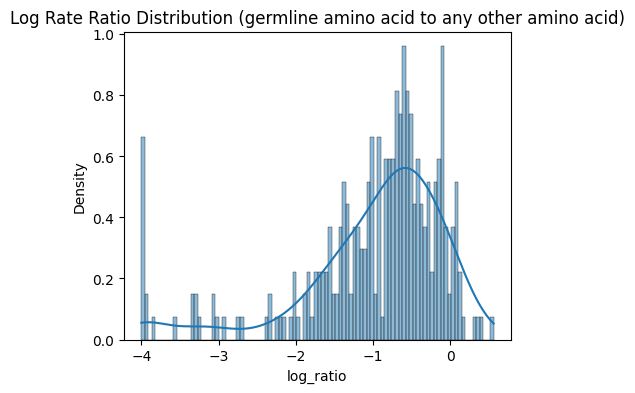

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.histplot(rates_summarized.log_ratio, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100)
ax.set_title('Log Rate Ratio Distribution (germline amino acid to any other amino acid)')


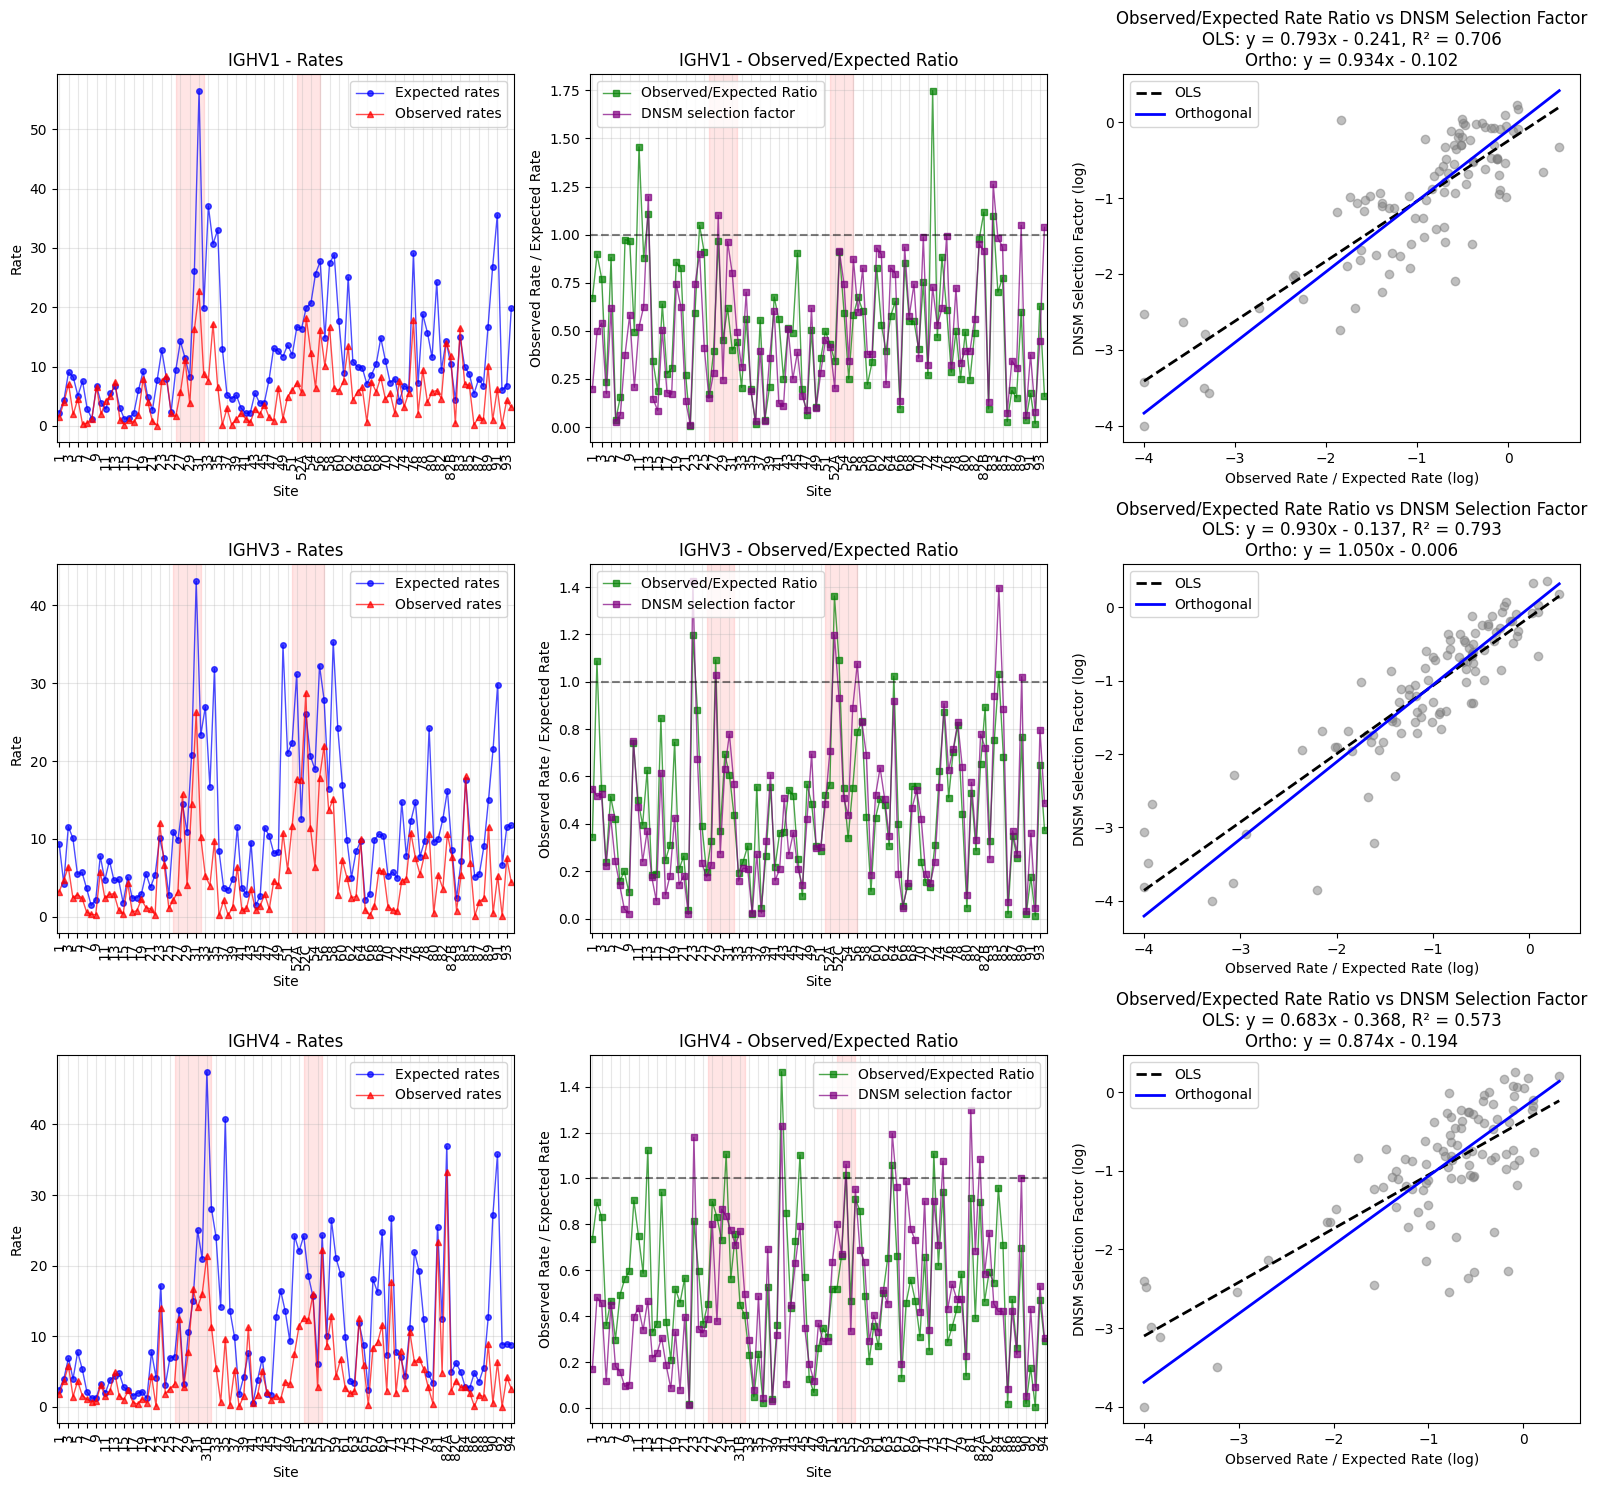

In [10]:
# plot the rates and rate ratio (observed / expected) for each v_family


fig, axes = plt.subplots(3, 3, figsize=(16, 15))
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, v_family in enumerate(v_families):
    # Filter and sort data for this v_family
    compare_rates_dnsm_family = compare_rates_dnsm[compare_rates_dnsm['v_family'] == v_family].copy()
    sorted_sites = sort_antibody_sites(compare_rates_dnsm_family['site'].unique())
    site_to_position = {site: idx for idx, site in enumerate(sorted_sites)}
    compare_rates_dnsm_family = compare_rates_dnsm_family.sort_values('site', key=lambda s: s.map(site_to_position))
    x_positions = [site_to_position[s] for s in compare_rates_dnsm_family['site']]

    # Left column - rates
    ax_rates = axes[i, 0]

    # Add CDR background regions using proper site-aware shading
    add_cdr_shading(ax_rates, sorted_sites, numbering_scheme=numbering_scheme)

    # Plot expected rates
    ax_rates.plot(x_positions, compare_rates_dnsm_family['rate_mutcount_expected'].values,
           'o-', alpha=0.7, label='Expected rates', color='blue', markersize=4, linewidth=1)

    # Plot observed rates
    ax_rates.plot(x_positions, compare_rates_dnsm_family['rate_mutcount_observed'].values,
           '^-', alpha=0.7, label='Observed rates', color='red', markersize=4, linewidth=1)

    # Formatting for rates column
    ax_rates.set_title(f'{v_family} - Rates')
    ax_rates.set_xlabel('Site')
    ax_rates.set_ylabel('Rate')
    ax_rates.legend()
    ax_rates.grid(True, alpha=0.3)

    # Set x-ticks every second value and rotate labels
    if len(sorted_sites) > 0:
        ax_rates.set_xlim(-0.5, len(sorted_sites) - 0.5)
        ax_rates.set_xticks(range(0, len(sorted_sites), 2))
        ax_rates.set_xticklabels([sorted_sites[j] for j in range(0, len(sorted_sites), 2)], rotation=90)

    # Middle column - ratio
    ax_ratio = axes[i, 1]

    # Add CDR background regions using proper site-aware shading
    add_cdr_shading(ax_ratio, sorted_sites, numbering_scheme=numbering_scheme)

    # Plot ratio and DNSM
    ax_ratio.plot(x_positions, compare_rates_dnsm_family['ratio'].values,
           's-', alpha=0.7, color='green', markersize=4, linewidth=1, label='Observed/Expected Ratio')
    ax_ratio.plot(x_positions, compare_rates_dnsm_family['selection_factor'].values,
            's-', alpha=0.7, color='purple', markersize=4, linewidth=1, label='DNSM selection factor')
    ax_ratio.legend()
    # Add horizontal line at y=1 for reference
    ax_ratio.axhline(y=1, color='black', linestyle='--', alpha=0.5)

    # Formatting for ratio column
    ax_ratio.set_title(f'{v_family} - Observed/Expected Ratio')
    ax_ratio.set_xlabel('Site')
    ax_ratio.set_ylabel('Observed Rate / Expected Rate')
    ax_ratio.grid(True, alpha=0.3)

    # Set x-ticks every second value and rotate labels
    if len(sorted_sites) > 0:
        ax_ratio.set_xlim(-0.5, len(sorted_sites) - 0.5)
        ax_ratio.set_xticks(range(0, len(sorted_sites), 2))
        ax_ratio.set_xticklabels([sorted_sites[j] for j in range(0, len(sorted_sites), 2)], rotation=90)


    # Right column - correlation
    ax_correlation = axes[i, 2]

    # Plot scatter points
    ax_correlation.scatter(compare_rates_dnsm_family['log_ratio'], 
                          compare_rates_dnsm_family['log_selection_factor'],
                          alpha=0.5, color='grey')

    ax_correlation.set_xlabel('Observed Rate / Expected Rate (log)')
    ax_correlation.set_ylabel('DNSM Selection Factor (log)')

    # Calculate regression statistics
    x = compare_rates_dnsm_family['log_ratio']
    y = compare_rates_dnsm_family['log_selection_factor']

    # Remove any NaN values for regression calculation
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # Calculate OLS linear regression
    slope_ols, intercept_ols, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    r_squared = r_value ** 2

    # Calculate orthogonal regression
    slope_ortho, intercept_ortho = orthogonal_regression(x_clean.values, y_clean.values)

    # Add both regression lines
    x_range = np.array([x_clean.min(), x_clean.max()])

    # OLS regression line (dashed black)
    y_ols = slope_ols * x_range + intercept_ols
    ax_correlation.plot(x_range, y_ols, linestyle='--', color='black', linewidth=2, label='OLS')

    # Orthogonal regression line (solid blue)
    y_ortho = slope_ortho * x_range + intercept_ortho
    ax_correlation.plot(x_range, y_ortho, linestyle='-', color='blue', linewidth=2, label='Orthogonal')

    ax_correlation.legend()

    # Format the equations for the title
    if intercept_ols >= 0:
        equation_ols = f'OLS: y = {slope_ols:.3f}x + {intercept_ols:.3f}'
    else:
        equation_ols = f'OLS: y = {slope_ols:.3f}x - {abs(intercept_ols):.3f}'

    if intercept_ortho >= 0:
        equation_ortho = f'Ortho: y = {slope_ortho:.3f}x + {intercept_ortho:.3f}'
    else:
        equation_ortho = f'Ortho: y = {slope_ortho:.3f}x - {abs(intercept_ortho):.3f}'

    title = f'Observed/Expected Rate Ratio vs DNSM Selection Factor\n{equation_ols}, R² = {r_squared:.3f}\n{equation_ortho}'
    ax_correlation.set_title(title)


plt.tight_layout()
plt.show()

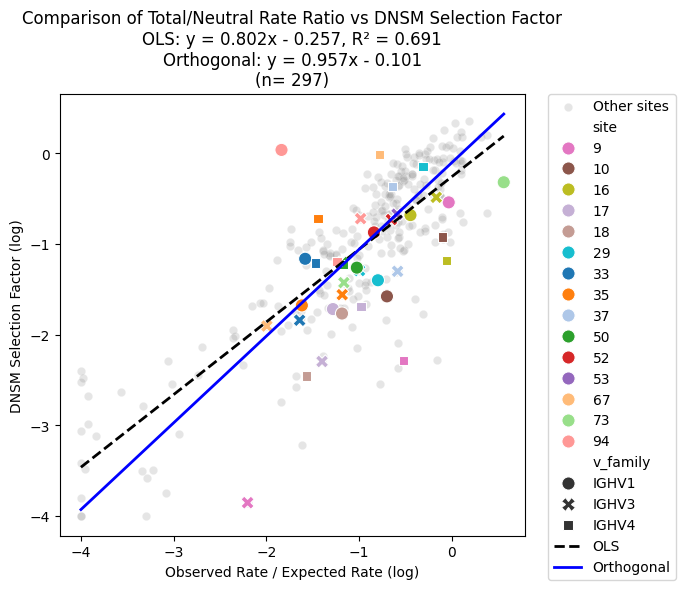

In [11]:
# Highlight all entrenched sites


# Calculate regression statistics
x = compare_rates_dnsm['log_ratio']
y = compare_rates_dnsm['log_selection_factor']

# Remove any NaN values for regression calculation
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# Calculate OLS linear regression
slope_ols, intercept_ols, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
r_squared = r_value ** 2
n_regression = len(x_clean)

# Calculate orthogonal regression
slope_ortho, intercept_ortho = orthogonal_regression(x_clean.values, y_clean.values)


# Create the plot
fig, ax = plt.subplots(figsize=(7, 6))

# Plot regular points in grey
sns.scatterplot(data=compare_rates_dnsm, 
                x='log_ratio', y='log_selection_factor', 
                color='grey', alpha=0.2, label='Other sites')


# filter entrenched data
entrenched_compare_rates_dnsm = pd.merge(entrenched_sites, compare_rates_dnsm, on=['site', 'v_family'], how='inner')
# plot entrenched points in color
entrenched_compare_rates_dnsm['site'] = entrenched_compare_rates_dnsm['site'].astype(str)
sns.scatterplot(data=entrenched_compare_rates_dnsm,
                x='log_ratio', y='log_selection_factor', 
                s=90, hue='site', style='v_family', palette=SITE_COLOR_MAP)

# Add both regression lines
x_range = np.array([x_clean.min(), x_clean.max()])

# OLS regression line (dashed black)
y_ols = slope_ols * x_range + intercept_ols
ax.plot(x_range, y_ols, linestyle='--', color='black', linewidth=2, label='OLS')

# Orthogonal regression line (solid blue)
y_ortho = slope_ortho * x_range + intercept_ortho
ax.plot(x_range, y_ortho, linestyle='-', color='blue', linewidth=2, label='Orthogonal')

# Add legend
plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


plt.xlabel('Observed Rate / Expected Rate (log)')
plt.ylabel('DNSM Selection Factor (log)')

# Format the equations for the title
if intercept_ols >= 0:
    equation_ols = f'OLS: y = {slope_ols:.3f}x + {intercept_ols:.3f}'
else:
    equation_ols = f'OLS: y = {slope_ols:.3f}x - {abs(intercept_ols):.3f}'

if intercept_ortho >= 0:
    equation_ortho = f'Orthogonal: y = {slope_ortho:.3f}x + {intercept_ortho:.3f}'
else:
    equation_ortho = f'Orthogonal: y = {slope_ortho:.3f}x - {abs(intercept_ortho):.3f}'

title = f'Comparison of Total/Neutral Rate Ratio vs DNSM Selection Factor\n{equation_ols}, R² = {r_squared:.3f}\n{equation_ortho}\n(n= {n_regression})'
plt.title(title)

plt.tight_layout()
plt.show()

## Rates per site, parent codon and child codon
- Let's use these rates to examine synoymous and non synonymous mutation differences. We expect synonymous mutations log rate ratio to cluster around 0, while the non synonymous log rate ratio will mostly be lower than 0.

In [12]:
observed_codon_df = pd.read_csv(f'{observed_output_base_path}_per_codon_mutation_rates.csv', dtype={'site':str})
expected_codon_df = pd.read_csv(f'{expected_output_base_path}_per_codon_mutation_rates.csv', dtype={'site':str})

In [13]:
# Merge data to calculate ratios at matching sites and AA changes
rates_codons_summarized = pd.merge(
        observed_codon_df[['site', 'parent_codon', 'child_codon', 'parent_aa', 'child_aa', 'rate_mutcount', 'rate_mutcount_adjusted', 'mutcount_length', 'mutation_acquired', 'mutation_acquired_adjusted', 'v_family']],
        expected_codon_df[['site', 'parent_codon', 'child_codon', 'parent_aa', 'child_aa', 'rate_mutcount', 'rate_mutcount_adjusted', 'mutcount_length', 'mutation_acquired', 'mutation_acquired_adjusted', 'v_family']],
        on=['site', 'parent_codon', 'child_codon', 'parent_aa', 'child_aa', 'v_family'],
        suffixes=('_observed', '_expected')
    )

# Use adjusted rates (with pseudocount already applied at count level)
rates_codons_summarized['ratio'] = rates_codons_summarized['rate_mutcount_adjusted_observed'] / rates_codons_summarized['rate_mutcount_adjusted_expected']
rates_codons_summarized['log_ratio'] = np.log(rates_codons_summarized['ratio'])

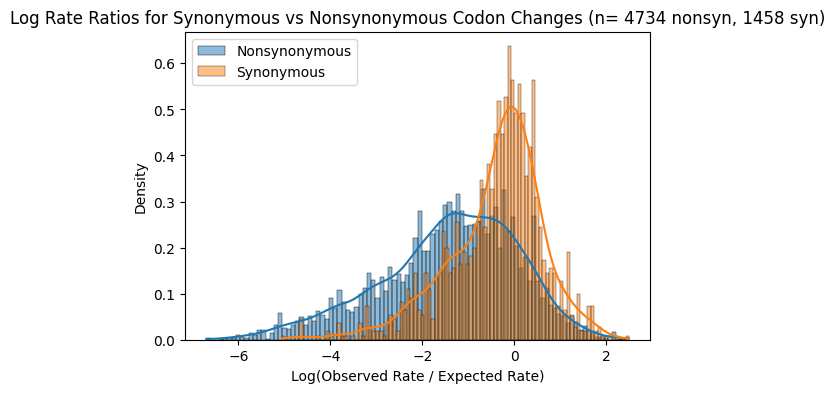

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data
nonsynonymous = rates_codons_summarized[
    (rates_codons_summarized.parent_aa != rates_codons_summarized.child_aa)
].log_ratio

synonymous = rates_codons_summarized[
    (rates_codons_summarized.parent_aa == rates_codons_summarized.child_aa)
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100)
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100)

ax.legend()
ax.set_xlabel('Log(Observed Rate / Expected Rate)')
ax.set_title('Log Rate Ratios for Synonymous vs Nonsynonymous Codon Changes (n= {} nonsyn, {} syn)'.format(len(nonsynonymous), len(synonymous)))
plt.show()

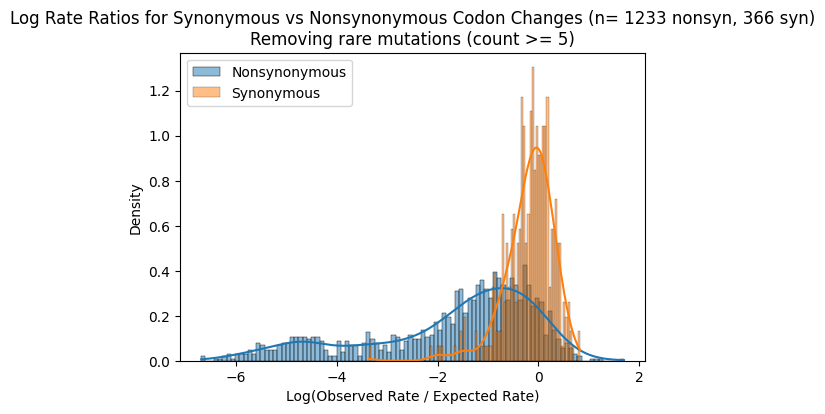

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data
nonsynonymous = rates_codons_summarized[
    (rates_codons_summarized.parent_aa != rates_codons_summarized.child_aa) &
    (rates_codons_summarized['mutation_acquired_expected'] >= 5)
].log_ratio

synonymous = rates_codons_summarized[
    (rates_codons_summarized.parent_aa == rates_codons_summarized.child_aa) &
    (rates_codons_summarized['mutation_acquired_expected'] >= 5)
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100)
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100)

ax.legend()
ax.set_xlabel('Log(Observed Rate / Expected Rate)')
ax.set_title('Log Rate Ratios for Synonymous vs Nonsynonymous Codon Changes (n= {} nonsyn, {} syn)\nRemoving rare mutations (count >= 5)'.format(len(nonsynonymous), len(synonymous)))

plt.show()

## Rates per site, parent aa and child aa

In [16]:
observed_aa_df = pd.read_csv(f'{observed_output_base_path}_per_aa_mutation_rates.csv', dtype={'site':str})
expected_aa_df = pd.read_csv(f'{expected_output_base_path}_per_aa_mutation_rates.csv', dtype={'site':str})

add_column_aa_one_mutation_away_from_aa(observed_aa_df, 'parent_aa', 'child_aa')
add_column_aa_one_mutation_away_from_aa(expected_aa_df, 'parent_aa', 'child_aa')

Adding one_mutation_away column (vectorized)...
Adding one_mutation_away column (vectorized)...


In [17]:
# Merge data to calculate ratios at matching sites and AA changes
rates_aa_summarized = pd.merge(
        observed_aa_df[['site', 'parent_aa', 'child_aa', 'rate_mutcount', 'rate_mutcount_adjusted', 'mutcount_length', 'mutation_acquired', 'mutation_acquired_adjusted', 'v_family', 'one_mutation_away']],
        expected_aa_df[['site', 'parent_aa', 'child_aa', 'rate_mutcount', 'rate_mutcount_adjusted', 'mutcount_length', 'mutation_acquired', 'mutation_acquired_adjusted', 'v_family', 'one_mutation_away']],
        on=['site', 'parent_aa', 'child_aa', 'v_family', 'one_mutation_away'],
        suffixes=('_observed', '_expected')
    )

# Use adjusted rates (with pseudocount already applied at count level)
rates_aa_summarized['ratio'] = rates_aa_summarized['rate_mutcount_adjusted_observed'] / rates_aa_summarized['rate_mutcount_adjusted_expected']
rates_aa_summarized['log_ratio'] = np.log(rates_aa_summarized['ratio'])

Text(0.5, 1.0, 'Log Rate Ratio Distribution (amino acid to amino acid)\nRemoving rare mutations (count >= 5)')

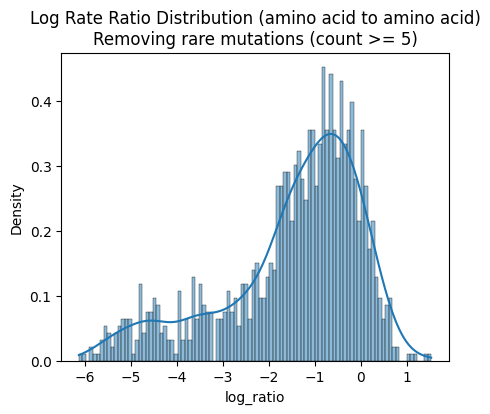

In [18]:

fig, ax = plt.subplots(figsize=(5, 4))
sns.histplot(rates_aa_summarized[rates_aa_summarized['mutation_acquired_expected'] >= 5].log_ratio, ax=ax, kde=True, stat='density', alpha=0.5, bins=100)
ax.set_title('Log Rate Ratio Distribution (amino acid to amino acid)\nRemoving rare mutations (count >= 5)')


In [19]:
### compare to DASM
_, _, aa_site_subs_selection_df_germline = load_and_process_dasm_data(model_name=dasm_compare_model_name, dataset_name=dasm_compare_dataset_name, numbering_scheme=numbering_scheme)


Adding one_mutation_away column (vectorized)...


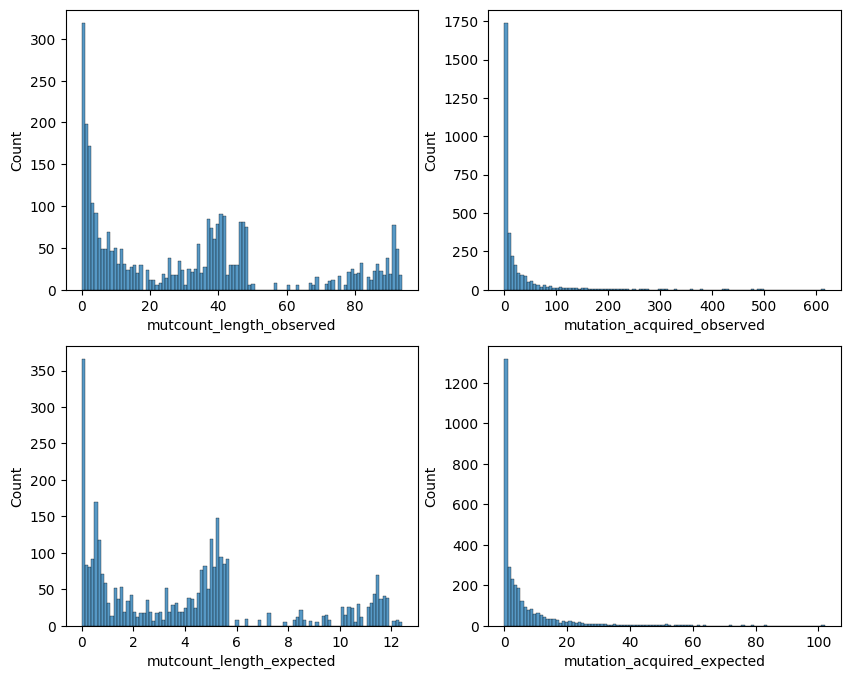

In [20]:
# Aggregate matching the entrenchment analysis in v_families_dasm.ipynb
before_grouping = aa_site_subs_selection_df_germline[
    (aa_site_subs_selection_df_germline.depth == 2) &
    (aa_site_subs_selection_df_germline.one_mutation_away == True) &
    (aa_site_subs_selection_df_germline.is_germline_codon == True)
].copy()
before_grouping.dropna(subset=['log_selection_factor'], inplace=True)

# Remove rare AAs (< 10 unique PCPs per v_family+site+parent_aa)
counts_of_aa_site_family = before_grouping[['v_family', 'site', 'parent_aa', 'pcp_index']].drop_duplicates().groupby(['v_family', 'site', 'parent_aa']).size().reset_index(name='count')
counts_of_aa_site_family = counts_of_aa_site_family[counts_of_aa_site_family['count'] >= 10]
before_grouping = pd.merge(before_grouping, counts_of_aa_site_family[['v_family', 'site', 'parent_aa']], on=['v_family', 'site', 'parent_aa'], how='inner')

dasm_summarized = before_grouping.groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index()

compare_dasm_rates = pd.merge(rates_aa_summarized, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
# Don't save CSV - this is a comparison notebook only


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for ax, column in enumerate(['mutcount_length_observed', 'mutation_acquired_observed', 'mutcount_length_expected', 'mutation_acquired_expected']):
    sns.histplot(compare_dasm_rates[compare_dasm_rates.one_mutation_away == True][column], ax=axes[ax], bins=100)

In [21]:
# plot_dasm_vs_rates_comparison and plot_rates_pairwise_analysis are now imported from rates_analysis_util
# They use standardized column names: 'observed_counts', 'expected_counts', 'log_ratio'

Plotting 83 entrenched points


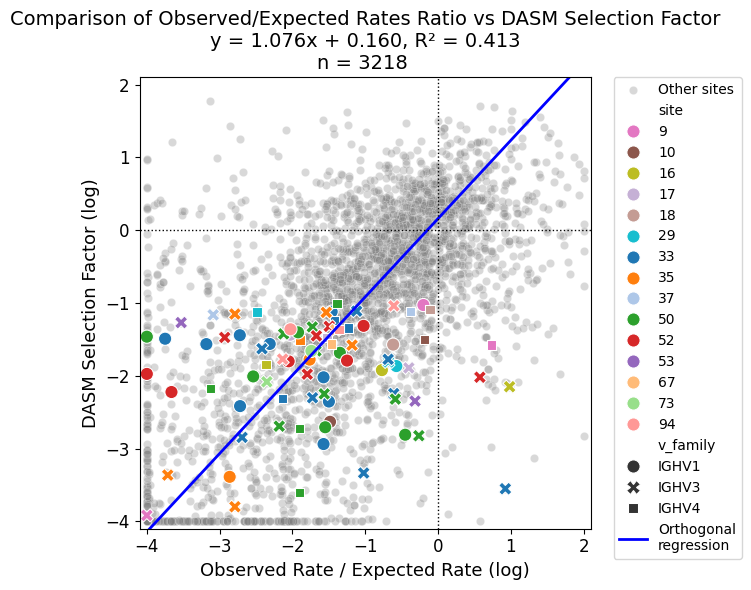

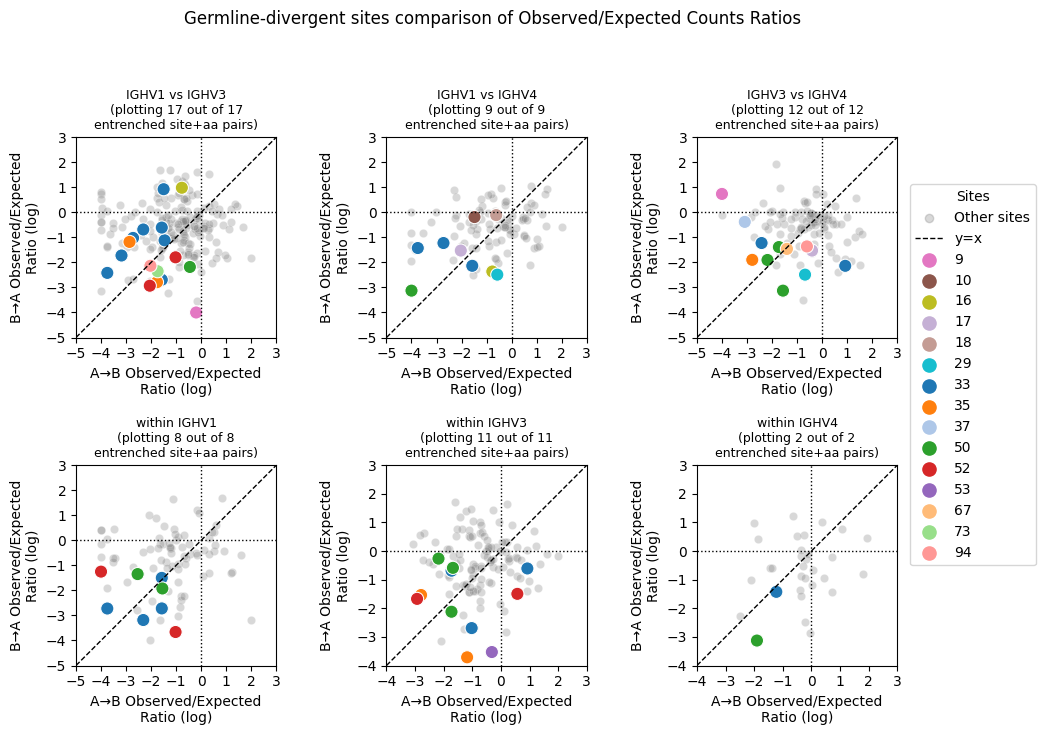

In [22]:
# Correlate all DASM selection factors with observed/expected rates for amino acid changes


compare_dasm_rates = pd.merge(rates_aa_summarized, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

# filter only sites with one mutation away (and part of the v gene)
compare_dasm_rates = compare_dasm_rates[(compare_dasm_rates.one_mutation_away == True)]

# Rename columns to standardized names for plotting functions
compare_dasm_rates = compare_dasm_rates.rename(columns={
    'mutation_acquired_observed': 'observed_counts',
    'mutation_acquired_expected': 'expected_counts'
})

plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, SITE_COLOR_MAP, savefig_prefix=None, title_extra='')
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP)

In [23]:
entrenched_compare_rates_dasm = pd.merge(compare_dasm_rates, entrenched_sites_aas.rename(columns={'amino_acid':'parent_aa', 'target_amino_acid':'child_aa'}), on=['site', 'parent_aa', 'child_aa', 'v_family'], how='inner')


entrenched_sites_test = entrenched_compare_rates_dasm.site.drop_duplicates().sort_values().tolist()
entrenched_sites_that_pass_filter_test = entrenched_compare_rates_dasm[(entrenched_compare_rates_dasm.expected_counts >= 5)].site.drop_duplicates().sort_values()

# find all sites that exist in entrenched_sites_test but not in entrenched_sites_that_pass_filter_test
print(set(entrenched_sites_test) - set(entrenched_sites_that_pass_filter_test))

# find all sites that exist in entrenched_sites_test and in entrenched_sites_that_pass_filter_test
print(set(entrenched_sites_test) & set(entrenched_sites_that_pass_filter_test))

{'17', '37', '53', '16'}
{'94', '18', '35', '9', '33', '50', '29', '10', '67', '52', '73'}


In [24]:
sites_that_lost_data_when_filtering = compare_dasm_rates[(compare_dasm_rates.expected_counts < 5)].site.drop_duplicates().sort_values()
all_sites = compare_dasm_rates.site.drop_duplicates().sort_values()

# find sites that do not lose substitutions to filtering
print(set(all_sites) - set(sites_that_lost_data_when_filtering))

{'91', '59'}


Plotting 21 entrenched points
The following entrenched points were not found in the comparison data:
     site v_family parent_aa child_aa
12     10    IGHV4         G        E
43     16    IGHV1         A        G
44     16    IGHV3         G        A
49     16    IGHV4         G        A
50     17    IGHV1         S        T
...   ...      ...       ...      ...
923    73    IGHV1         K        N
1163    9    IGHV3         G        A
1165    9    IGHV4         A        G
1232   94    IGHV1         T        K
1238   94    IGHV3         T        R

[62 rows x 4 columns]


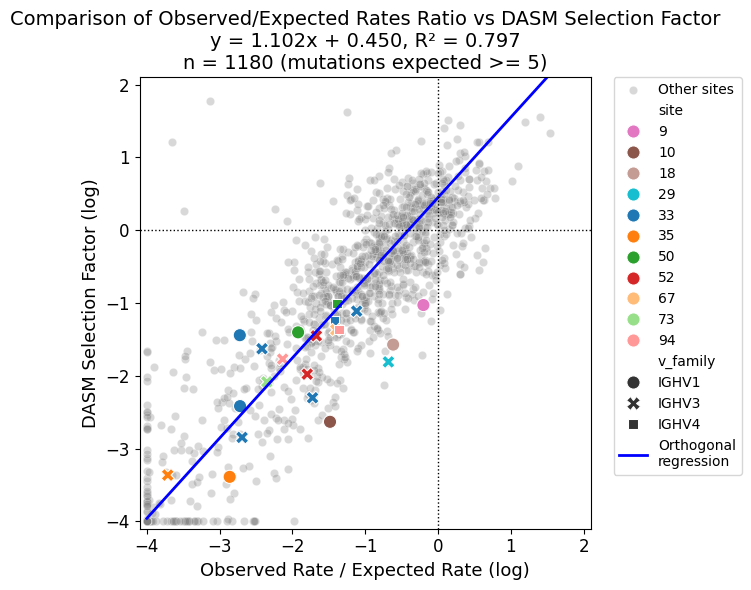

/home/nharel/re/dasm-epistasis-experiments/rates_analysis_util.py:657: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(entrenched_merged_pairwise, x='log_ratio_1', y='log_ratio_2',
/home/nharel/re/dasm-epistasis-experiments/rates_analysis_util.py:657: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(entrenched_merged_pairwise, x='log_ratio_1', y='log_ratio_2',
/home/nharel/re/dasm-epistasis-experiments/rates_analysis_util.py:657: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(entrenched_merged_pairwise, x='log_ratio_1', y='log_ratio_2',
/home/nharel/re/dasm-epistasis-experiments/rates_analysis_util.py:657: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(entrenched_merged_pairwise, x='log_ratio_1', y='log_ratio_2',
/home/nharel/re/dasm-epistasis-experiments/rates_analysis_util.py:657: UserWarning: Igno

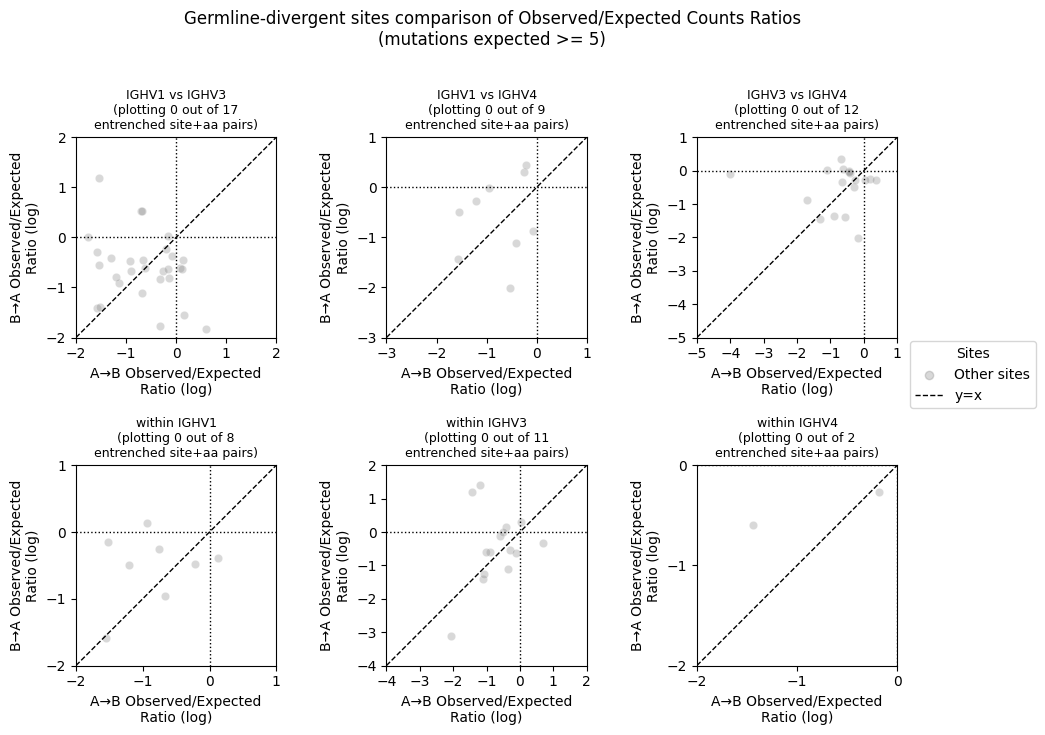

In [25]:
# Correlate DASM selection factors with observed/expected rates for amino acid changes that pass filter (compare_dasm_rates['mutation_acquired_expected'] >= 5) & (compare_dasm_rates.one_mutation_away == True) & (compare_dasm_rates['mutcount_length_observed'] >= compare_dasm_rates['mutcount_length_expected'])



compare_dasm_rates = pd.merge(rates_aa_summarized, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

# filter only sites with sufficient data, and one mutation away
compare_dasm_rates = compare_dasm_rates[(compare_dasm_rates['mutation_acquired_expected'] >= 5) & (compare_dasm_rates.one_mutation_away == True)]

# Rename columns to standardized names for plotting functions
compare_dasm_rates = compare_dasm_rates.rename(columns={
    'mutation_acquired_observed': 'observed_counts',
    'mutation_acquired_expected': 'expected_counts'
})

# No savefig_prefix - this is a comparison notebook only
plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, 
                              SITE_COLOR_MAP, 
                              title="Comparison of Observed/Expected Rates Ratio vs DASM Selection Factor",
                              title_extra='(mutations expected >= 5)')

plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP, 
                             title_extra='(mutations expected >= 5)')